In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import pandas as pd
df = pd.read_csv('../data/Walmart.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (6435, 8)

First 5 rows:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
print("Column names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Column names: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Data types:
 Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Missing values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [8]:
# Fix date column
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

# Basic statistics
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nNumber of stores:", df['Store'].nunique())
print("\nTotal weeks of data:", df['Date'].nunique())
print("\nBasic statistics:")
df.describe()

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Number of stores: 45

Total weeks of data: 143

Basic statistics:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [10]:
# Extract useful time features from date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

print("New columns added:")
df[['Date', 'Year', 'Month', 'Week', 'Quarter']].head(10)

New columns added:


,Date,Year,Month,Week,Quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1
5,2010-03-12,2010,3,10,1
6,2010-03-19,2010,3,11,1
7,2010-03-26,2010,3,12,1
8,2010-04-02,2010,4,13,2
9,2010-04-09,2010,4,14,2


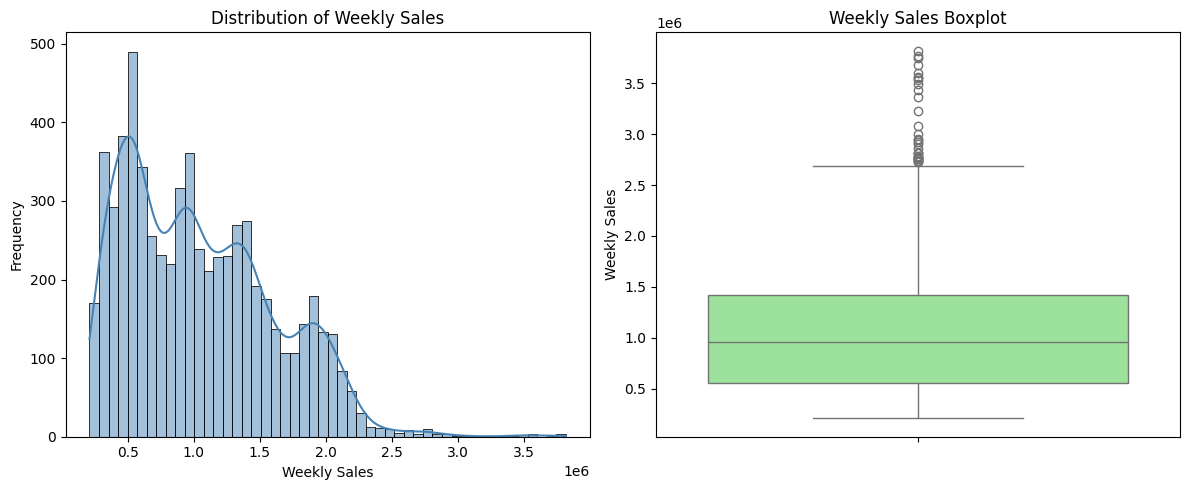

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Weekly_Sales'], bins=50, color='steelblue', kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Weekly_Sales'], color='lightgreen')
plt.title('Weekly Sales Boxplot')
plt.ylabel('Weekly Sales')

plt.tight_layout()
plt.savefig('../outputs/graphs/01_sales_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

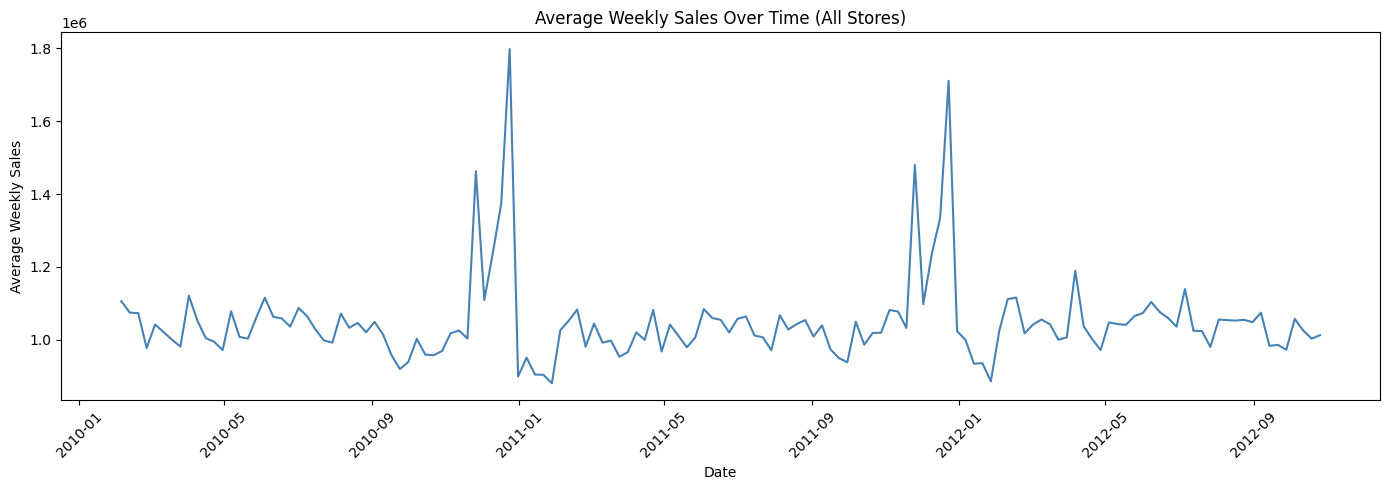

In [16]:
sales_over_time = df.groupby('Date')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(sales_over_time['Date'], 
         sales_over_time['Weekly_Sales'], 
         color='steelblue', 
         linewidth=1.5)
plt.title('Average Weekly Sales Over Time (All Stores)')
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/graphs/02_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\sahoo\AppData\Local\Temp\ipykernel_28348\3635037428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Holiday_Flag',


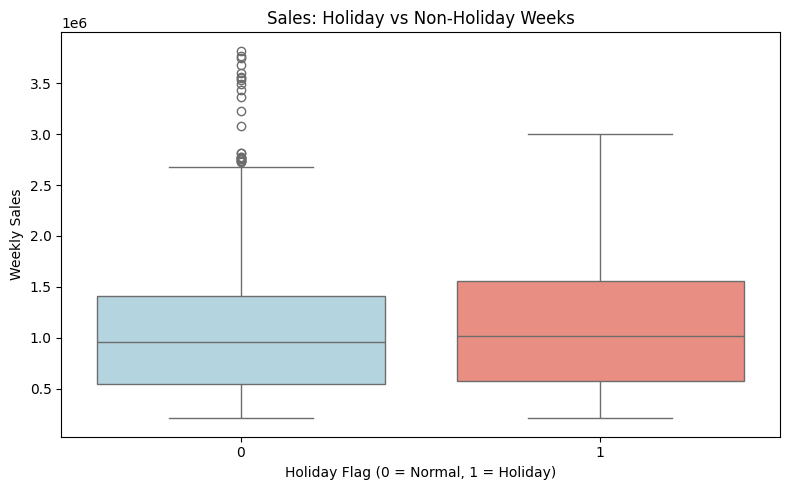

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday_Flag', 
            y='Weekly_Sales', 
            data=df, 
            palette=['lightblue', 'salmon'])
plt.title('Sales: Holiday vs Non-Holiday Weeks')
plt.xlabel('Holiday Flag (0 = Normal, 1 = Holiday)')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.savefig('../outputs/graphs/03_holiday_impact.png', dpi=300, bbox_inches='tight')
plt.show()

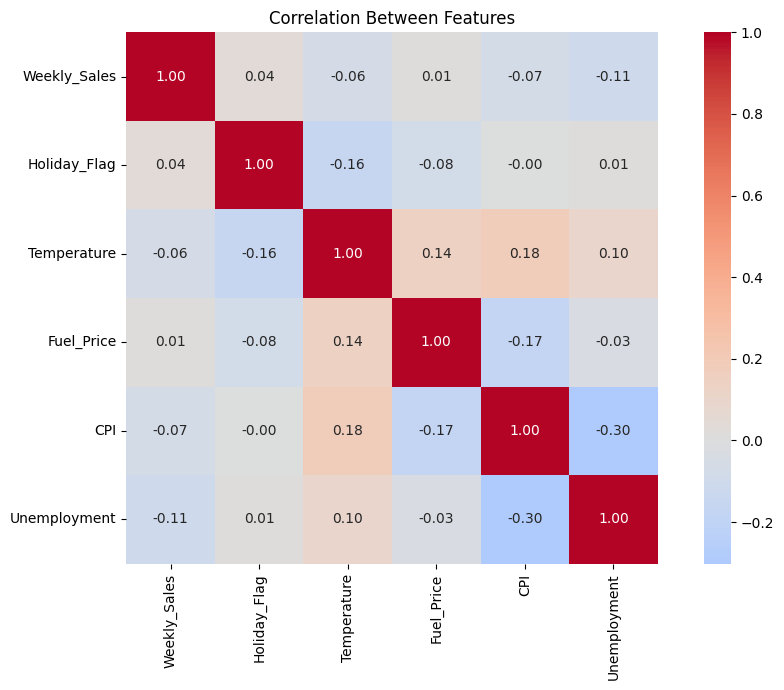

In [18]:
plt.figure(figsize=(10, 7))
correlation = df[['Weekly_Sales', 'Holiday_Flag', 'Temperature', 
                   'Fuel_Price', 'CPI', 'Unemployment']].corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Between Features')
plt.tight_layout()
plt.savefig('../outputs/graphs/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

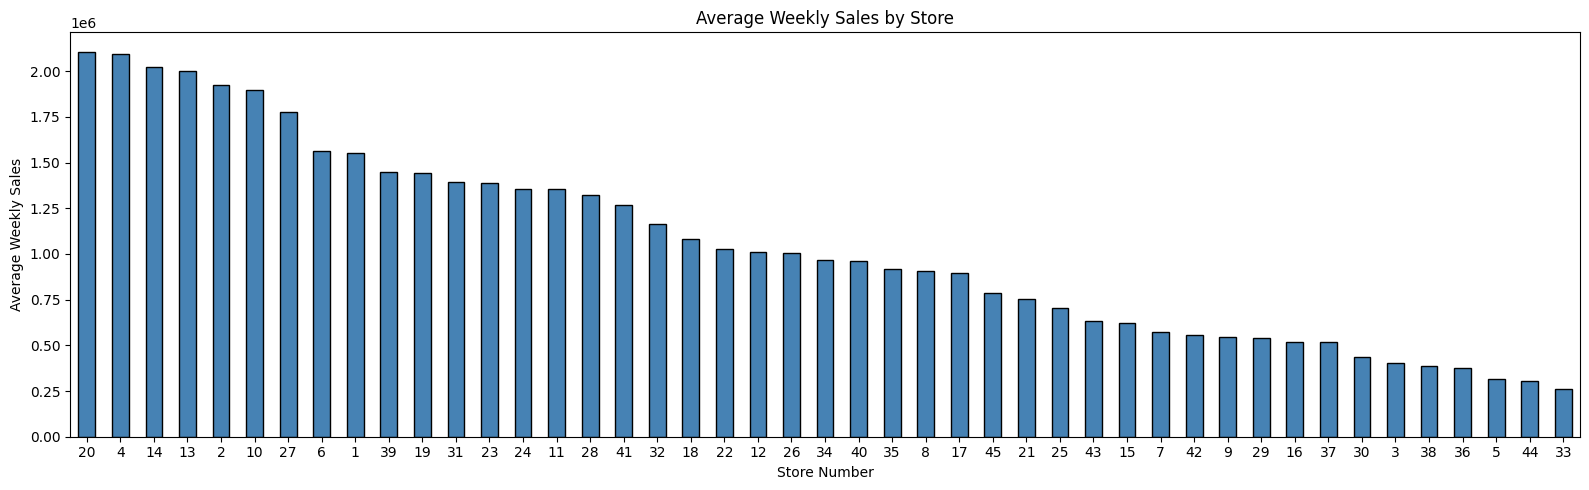

In [19]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
store_sales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Weekly Sales by Store')
plt.xlabel('Store Number')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/graphs/05_sales_by_store.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\sahoo\AppData\Local\Temp\ipykernel_28348\931967011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Weekly_Sales', data=monthly_sales, palette='Blues_d')


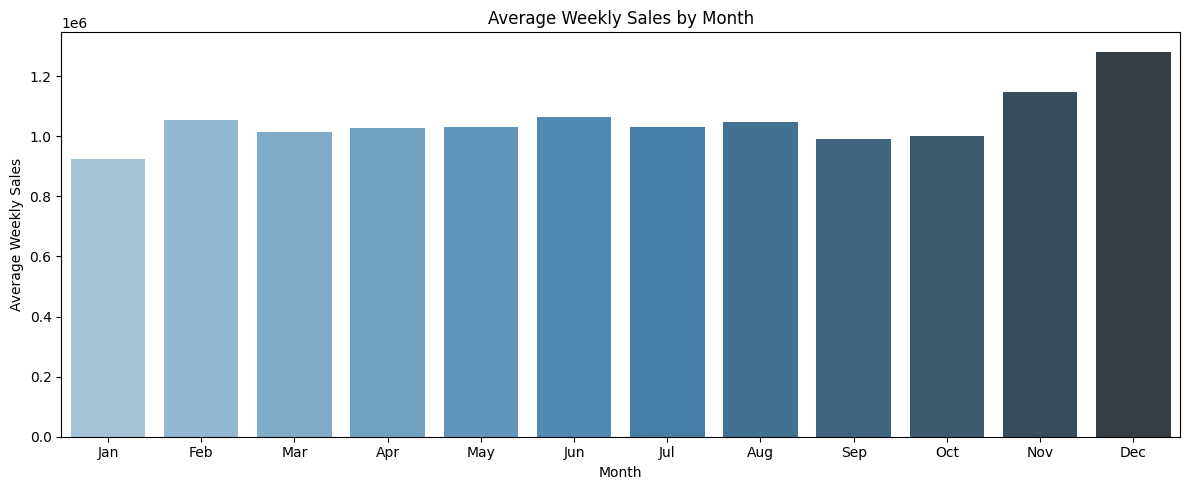

In [20]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
sns.barplot(x='Month', y='Weekly_Sales', data=monthly_sales, palette='Blues_d')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(ticks=range(12), labels=month_names)
plt.tight_layout()
plt.savefig('../outputs/graphs/06_monthly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()